In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [13]:
data = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\neuroharmonize\osc_pw_rel_roiF_SITE_age_sex_neuroharmonize.xlsx"
df_unharmonize = pd.read_excel(data, sheet_name='unharmonizeSITE_age_sex')
df_harmonize = pd.read_excel(data, sheet_name='harmonizeSITE_age_sex')

features = list(df_unharmonize.columns[5:-6])
print(features)

['osc_pw_theta_roiF', 'osc_pw_BGF1_roiF', 'osc_pw_BGF2_roiF', 'osc_pw_BGF3_roiF', 'osc_pw_beta_roiF']


C:\Users\Luisa\AppData\Local\Temp\ipykernel_22836\2442823355.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Variable', data=vif_data, palette='viridis')


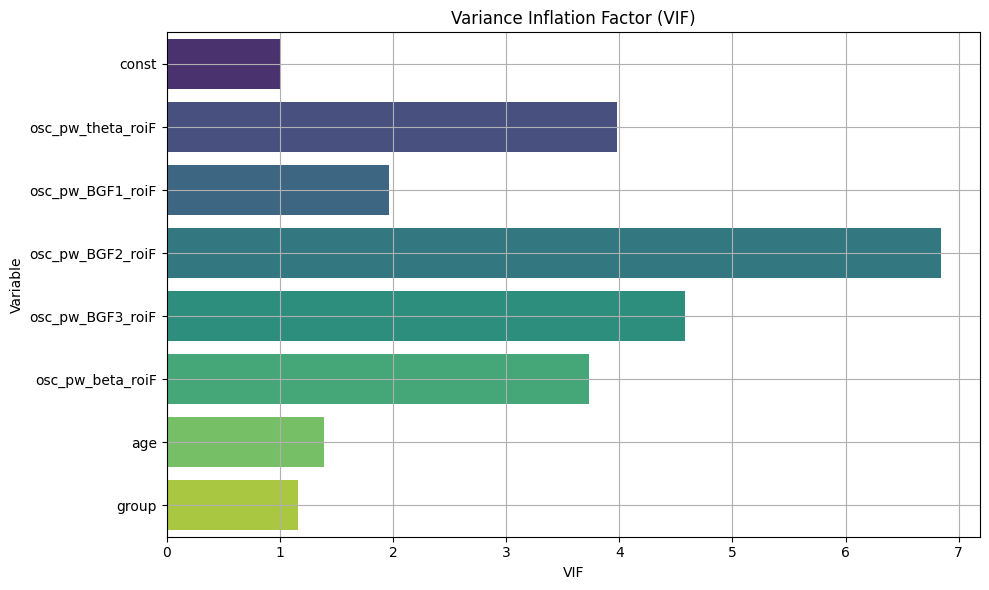

,Variable,VIF
3,osc_pw_BGF2_roiF,6.845634
4,osc_pw_BGF3_roiF,4.584649
1,osc_pw_theta_roiF,3.983197
5,osc_pw_beta_roiF,3.734013
2,osc_pw_BGF1_roiF,1.964950
6,age,1.387951
7,group,1.159916
0,const,1.000000


In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import numpy as np


# Crear copia del DataFrame sin NaNs y con sitios con al menos 20 sujetos
df_filtered = df_unharmonize[features + ['age', 'group', 'SITE']].dropna()
site_counts = df_filtered['SITE'].value_counts()
valid_sites = site_counts[site_counts >= 20].index
df_filtered = df_filtered[df_filtered['SITE'].isin(valid_sites)]

# Codificación de variables categóricas
df_filtered['group'] = pd.Categorical(df_filtered['group']).codes

# Estandarizar las variables predictoras
X_data = df_filtered[features + ['age', 'group']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)
X = sm.add_constant(X_scaled)

# Calcular VIF
vif_data = pd.DataFrame({
    'Variable': ['const'] + features + ['age', 'group'],
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Gráfico de VIF
plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='Variable', data=vif_data, palette='viridis')
plt.title('Variance Inflation Factor (VIF)')
plt.tight_layout()
plt.grid(True)
plt.show()

vif_data.sort_values('VIF', ascending=False)


In [10]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.sm_exceptions import PerfectSeparationError
import matplotlib.pyplot as plt
import numpy as np

def run_multinomial_logit(df, features, covariates, site_col='SITE', min_subjects=18):
    cols = features + covariates + [site_col]
    df = df[cols].dropna()

    # Excluir sitios con pocos sujetos
    valid_sites = df[site_col].value_counts()
    valid_sites = valid_sites[valid_sites >= min_subjects].index
    df = df[df[site_col].isin(valid_sites)].copy()

    # Codificar covariables categóricas si es necesario
    for cov in covariates:
        if df[cov].dtype == 'object':
            df[cov] = pd.Categorical(df[cov]).codes

    y = pd.Categorical(df[site_col]).codes

    # Estándarizar variables predictoras
    X_data = df[features + covariates]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    X = sm.add_constant(X_scaled)

    try:
        model = sm.MNLogit(y, X).fit(disp=1)
        print(model.summary())
        return model, df, features, covariates
    except PerfectSeparationError:
        print("[!] Error: Separación perfecta en los datos.")
        return None, None, None, None
    except Exception as e:
        print(f"[!] Error general: {e}")
        return None, None, None, None


def extract_std_betas_from_model(model, X_data, features):
    try:
        params = model.params  # ndarray (n_features x n_classes-1)
        stds = X_data[features].std()

        betas_std = pd.Series(index=features, dtype=float)
        for i, feat in enumerate(features):
            betas_std[feat] = (params[i + 1, :] * stds[feat]).mean()
        return betas_std
    except Exception as e:
        return f"[!] Error al extraer betas: {e}"


def plot_betas_comparison(features, betas_unharm, betas_harm, title='Multinomial Logistic Regression'):
    plt.figure(figsize=(10, 6))
    index = np.arange(len(features))
    bar_width = 0.35

    plt.bar(index, betas_unharm, bar_width, label='Unharmonized')
    plt.bar(index + bar_width, betas_harm, bar_width, label='Harmonized')

    plt.xlabel('Features')
    plt.ylabel('Standardized Beta Coefficient')
    plt.title(title)
    plt.xticks(index + bar_width / 2, features, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(axis='x')
    plt.show()


REGRESIÓN SIN ARMONIZAR
Optimization terminated successfully.
         Current function value: 1.147067
         Iterations 11
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                  868
Model:                        MNLogit   Df Residuals:                      812
Method:                           MLE   Df Model:                           49
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.3209
Time:                        16:35:15   Log-Likelihood:                -995.65
converged:                       True   LL-Null:                       -1466.2
Covariance Type:            nonrobust   LLR p-value:                2.411e-165
       y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.4088      1.202      5.333      0.000       4.053       8.764
x1  

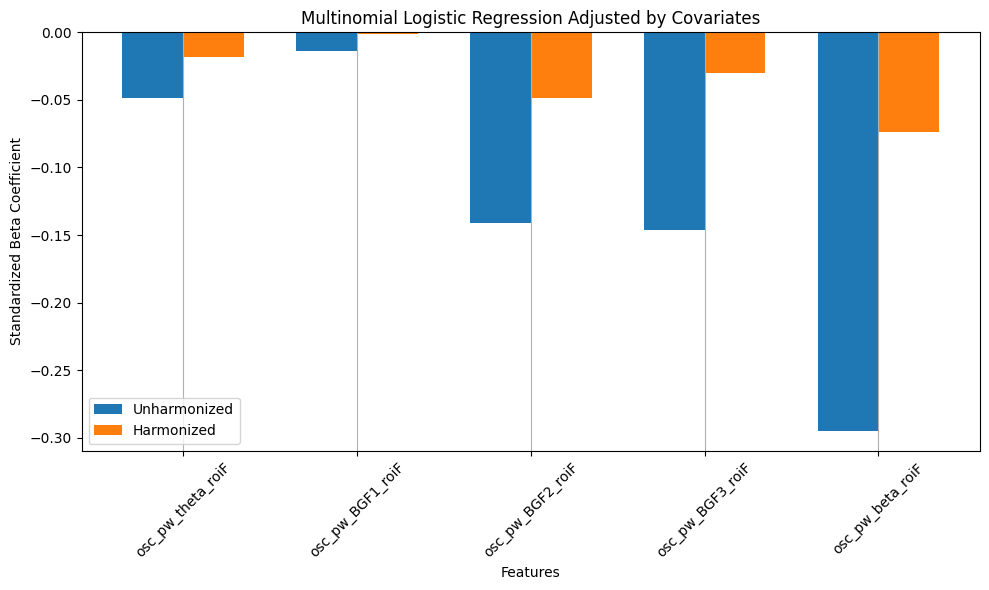

In [14]:
covariates = ['age', 'sex']  # <-- Puedes cambiar esto por ['sex'] o lo que tengas

# SIN ARMONIZAR
print("REGRESIÓN SIN ARMONIZAR")
model_unharm, df_unharm_used, feats_u, covs_u = run_multinomial_logit(df_unharmonize, features, covariates)
betas_unharm = extract_std_betas_from_model(model_unharm, df_unharm_used[feats_u + covs_u], feats_u)

# ARMONIZADA
harm_features = [f'harm_{f}' for f in features]
print("REGRESIÓN ARMONIZADA")
model_harm, df_harm_used, feats_h, covs_h = run_multinomial_logit(df_harmonize, harm_features, covariates)
betas_harm = extract_std_betas_from_model(model_harm, df_harm_used[feats_h + covs_h], feats_h)

# GRAFICAR
plot_betas_comparison(features, betas_unharm, betas_harm, title='Multinomial Logistic Regression Adjusted by Covariates')
